# 05 - End-to-End Demo

This notebook stitches the package-facing stages together for a small example subset. It is meant as a workflow sketch for future pipeline integration, not as a full-basin production run.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from stormlab.config import NoiseGenerationConfig, TrackingConfig
from stormlab.noise import generate_noise, linear_interpolation, temporal_autocorrelation
from stormlab.simulation import simulate_rainfall
from stormlab.tracking import track_rainstorms

In [2]:
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data").exists() and (REPO_ROOT.parent / "data").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_ROOT = REPO_ROOT / "data"
OUTPUT_ROOT = REPO_ROOT / "output" / "examples_pipeline"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO_ROOT}")
print(f"Data root exists: {DATA_ROOT.exists()}")

Repo root: c:\Users\ah5766\OneDrive - Halff\Documents\Code\StormLab
Data root exists: True


In [3]:
ar_id = 202200018
cesm_year_dir = DATA_ROOT / "cesm2" / "bias_corrected_annual_cesm2" / "1251_18" / "2022"
covariate_dir = DATA_ROOT / "cesm2" / "cesm2_rainstorm_covariates"
matched_rainfall_dir = DATA_ROOT / "cesm2" / "matched_aorc_rainfall"
param_dir = DATA_ROOT / "cesm2" / "cesm2_rainstorms_distr_params"

ivt = xr.open_dataset(cesm_year_dir / "CESM2_2022_ivt_bs.nc")["ivt"].data
coarse_prcp = xr.open_dataset(covariate_dir / f"{ar_id}_prect_cesm_res.nc")["prect"].data
aorc_rainfall = np.load(matched_rainfall_dir / f"{ar_id}_sr_rainfall.npy")
u_coarse = xr.open_dataset(covariate_dir / f"{ar_id}_u850_cesm_res.nc")["u850"].data
v_coarse = xr.open_dataset(covariate_dir / f"{ar_id}_v850_cesm_res.nc")["v850"].data

wet_probability = xr.open_dataset(param_dir / f"{ar_id}_logit_wet_p.nc")["aorc"].data
gamma_shape = xr.open_dataset(param_dir / f"{ar_id}_scipy_a.nc")["aorc"].data
gg_c = xr.open_dataset(param_dir / f"{ar_id}_scipy_c.nc")["aorc"].data
gamma_scale = xr.open_dataset(param_dir / f"{ar_id}_scipy_scale.nc")["aorc"].data

In [4]:
time_subset = slice(0, 4)
y_subset = slice(240, 368)
x_subset = slice(420, 548)

aorc_lat = np.linspace(50, 29, 630)
aorc_lon = np.linspace(-113.16734, -79.068704, 1024)
cesm_lat = np.linspace(50.41884817, 28.7434555, 24)
cesm_lon = np.linspace(-113.75, -78.75, 29)
sub_lat = aorc_lat[y_subset]
sub_lon = aorc_lon[x_subset]

In [5]:
tracking_config = TrackingConfig()
tracks = track_rainstorms(ivt[time_subset], tracking_config)
print(f"Tracked subset shape: {tracks.shape}")

Tracked subset shape: (4, 24, 29)


In [6]:
sub_prcp = np.where(aorc_rainfall[time_subset, y_subset, x_subset] < 0.2, 0, aorc_rainfall[time_subset, y_subset, x_subset])
acf = temporal_autocorrelation(coarse_prcp)[time_subset]

u_high = np.zeros_like(sub_prcp)
v_high = np.zeros_like(sub_prcp)
for t in range(sub_prcp.shape[0]):
    u_high[t] = linear_interpolation(u_coarse[t], cesm_lon, cesm_lat, sub_lon, sub_lat)
    v_high[t] = linear_interpolation(v_coarse[t], cesm_lon, cesm_lat, sub_lon, sub_lat)

noise = generate_noise(
    sub_prcp,
    acf,
    u_high * 3600 * 6,
    v_high * 3600 * 6,
    sub_lon,
    sub_lat,
    NoiseGenerationConfig(window_size=(64, 64), seed=1),
)

C:\Users\ah5766\OneDrive - Halff\Documents\Code\StormLab\src\noise_generation.py:36: RuntimeWarning: invalid value encountered in divide
  F.imag = (F.imag - np.mean(F.imag)) / np.std(F.imag)
C:\Users\ah5766\OneDrive - Halff\Documents\Code\StormLab\src\noise_generation.py:37: RuntimeWarning: invalid value encountered in divide
  F.real = (F.real - np.mean(F.real)) / np.std(F.real)


In [7]:
simulated = simulate_rainfall(
    noise,
    wet_probability[time_subset, y_subset, x_subset],
    gamma_shape[time_subset, y_subset, x_subset],
    gamma_scale[time_subset, y_subset, x_subset],
    gg_c[y_subset, x_subset],
)

print(f"Noise: {noise.shape}, mean/std {noise.mean():.3f}/{noise.std():.3f}")
print(f"Simulated rainfall: {simulated.shape}, mean/max {simulated.mean():.3f}/{simulated.max():.3f}")

Noise: (4, 128, 128), mean/std nan/nan
Simulated rainfall: (4, 128, 128), mean/max 0.360/23.653


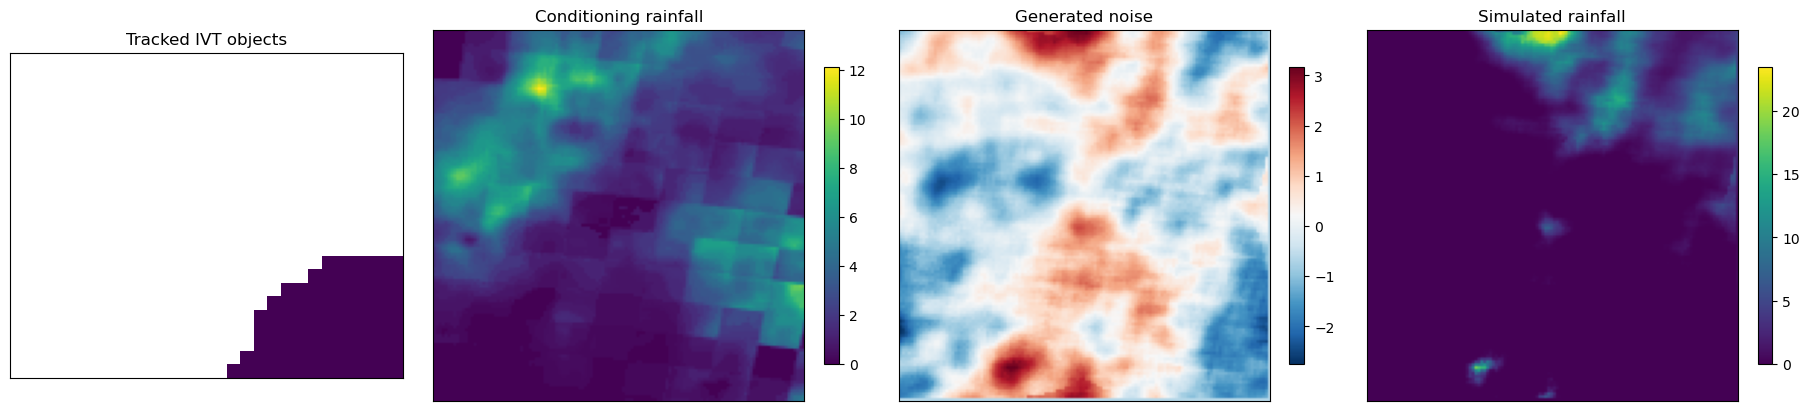

In [8]:
time_index = 0
fig, axes = plt.subplots(1, 4, figsize=(18, 4), constrained_layout=True)

axes[0].imshow(np.ma.masked_where(tracks[time_index] == 0, tracks[time_index]), origin="upper")
axes[0].set_title("Tracked IVT objects")

im1 = axes[1].imshow(sub_prcp[time_index], origin="upper")
axes[1].set_title("Conditioning rainfall")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].imshow(noise[time_index], origin="upper", cmap="RdBu_r")
axes[2].set_title("Generated noise")
fig.colorbar(im2, ax=axes[2], shrink=0.8)

im3 = axes[3].imshow(simulated[time_index], origin="upper")
axes[3].set_title("Simulated rainfall")
fig.colorbar(im3, ax=axes[3], shrink=0.8)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()